# CDC Influenza Surveillance Data Pipeline

Loads, processes, and pushes CDC surveillance data to HuggingFace for the
**Latent-Informed Epidemiological Modelling** project.

Data is downloaded from the project's HuggingFace dataset repo
([sidms/AML](https://huggingface.co/datasets/sidms/AML)) which hosts the
FluView zip originally obtained from CDC FluView Interactive.

## Data Sources
| Source | What it provides | Role in project |
|--------|-----------------|------------------|
| **ILINet** | Weekly % ILI visits (syndromic) | Context — NOT primary validation |
| **WHO/NREVSS Clinical Labs** | Weekly positive tests by type (A/B) | Seasonal positivity curves |
| **WHO/NREVSS Public Health Labs** | Subtyping: H1N1pdm09, H3N2, B lineages | **Dominant subtype per season** |
| **FluSurv-NET** | Hospitalisation rates per 100k | **Primary validation target** |
| **CDC Burden Estimates** | Annual illnesses, hospitalisations, deaths | **Economic validation layer** |

## Key Conventions
- **Season alignment:** MMWR week 40 → week 39 (e.g., 2017 wk40 through 2018 wk39 = "2017-18")
- **COVID exclusion:** 2020-21 flagged — extremely low flu activity due to NPIs
- **Coverage:** 2010-11 through latest available
- **FluSurv-NET caveat:** Covers ~10% of U.S. population; rates may not be nationally representative

In [1]:
import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["HF_HUB_DISABLE_IMPLICIT_TOKEN"] = "1"

!pip install -q datasets huggingface_hub pandas requests matplotlib

from huggingface_hub.utils import disable_progress_bars
disable_progress_bars()

In [ ]:
import pandas as pd
import numpy as np
import requests
import zipfile
import io
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from google.colab import userdata
HF_TOKEN = userdata.get('HF_TOKEN')
import warnings
warnings.filterwarnings('ignore')

HF_REPO = "sidms/AML"
FIRST_SEASON_YEAR = 2009
COVID_SEASON = "2020-21"  # COVID NPIs basically wiped out flu

# the zip lives on our HuggingFace dataset repo
CDC_ZIP_URL = "https://huggingface.co/datasets/sidms/AML/resolve/main/cdc_data/FluViewPhase2Data.zip"

OUTPUT_DIR = "cdc_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"CDC zip URL: {CDC_ZIP_URL}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"HuggingFace repo: {HF_REPO}")

In [3]:
def assign_season(year, week):
    """MMWR week 40+ belongs to current year's season, earlier weeks to the previous year's."""
    year, week = int(year), int(week)
    if week >= 40:
        start_year = year
    else:
        start_year = year - 1
    end_short = str(start_year + 1)[-2:]
    return f"{start_year}-{end_short}"


def is_covid_season(season):
    return season == COVID_SEASON


def safe_numeric(series):
    """CDC CSVs sometimes have 'X' or blanks in numeric columns :("""
    return pd.to_numeric(series.astype(str).str.strip(), errors='coerce')


def add_season_cols(df, year_col='YEAR', week_col='WEEK'):
    """Add season and covid_excluded columns."""
    df = df.copy()
    df[year_col] = safe_numeric(df[year_col])
    df[week_col] = safe_numeric(df[week_col])
    df = df.dropna(subset=[year_col, week_col])
    df[year_col] = df[year_col].astype(int)
    df[week_col] = df[week_col].astype(int)
    df['season'] = df.apply(lambda r: assign_season(r[year_col], r[week_col]), axis=1)
    df['covid_excluded'] = df['season'].apply(is_covid_season)
    return df


# quick sanity check
assert assign_season(2017, 42) == '2017-18'
assert assign_season(2018, 12) == '2017-18'
assert assign_season(2020, 40) == '2020-21'
print('Helper functions OK')

Helper functions OK


## Step 1: Download ILINet + WHO/NREVSS from HuggingFace

The `FluViewPhase2Data.zip` is hosted on the project's HuggingFace dataset repo
([sidms/AML](https://huggingface.co/datasets/sidms/AML/tree/main/cdc_data)).
It contains CSVs originally downloaded from
[FluView Interactive](https://gis.cdc.gov/grasp/fluview/fluportaldashboard.html)
(National, all seasons from 2010-11 onward).

**To refresh:** Re-download from FluView Interactive and update the file on HuggingFace.

In [4]:
print(f"Downloading FluView zip from HuggingFace...")
print(f"  URL: {CDC_ZIP_URL}")
resp = requests.get(CDC_ZIP_URL, timeout=60)
resp.raise_for_status()
print(f"  Downloaded: {len(resp.content):,} bytes")

z = zipfile.ZipFile(io.BytesIO(resp.content))

# each CDC CSV has a description row before the actual headers, so we use header=1
raw_dfs = {}
print(f"\nFiles in zip:")
for name in z.namelist():
    if name.endswith('.csv'):
        with z.open(name) as f:
            raw_dfs[name] = pd.read_csv(f, header=1)
            print(f"  {name}: {raw_dfs[name].shape[0]:,} rows x {raw_dfs[name].shape[1]} cols")

print("\nLoad complete.")

  URL: https://huggingface.co/datasets/sidms/AML/resolve/main/cdc_data/FluViewPhase2Data.zip
  Downloaded: 79,133 bytes

Files in zip:
  ICL_NREVSS_Combined_prior_to_2015_16.csv: 940 rows x 14 cols
  ILINet.csv: 1,483 rows x 15 cols
  ICL_NREVSS_Public_Health_Labs.csv: 543 rows x 13 cols
  ICL_NREVSS_Clinical_Labs.csv: 543 rows x 10 cols

Load complete.


## Step 2: Process ILINet (Syndromic Surveillance)

ILINet provides weekly **% of outpatient visits for influenza-like illness** (fever >= 100°F + cough/sore throat).

> **Important:** ILINet is syndromic and not subtype-specific. Do NOT use as the sole validation target.
> Use alongside WHO/NREVSS lab data and FluSurv-NET hospitalisation rates.

In [5]:
ilinet_key = [k for k in raw_dfs if 'ILINet' in k][0]
ilinet_raw = raw_dfs[ilinet_key].copy()
ilinet_raw.columns = ilinet_raw.columns.str.strip()

print(f"Raw ILINet columns: {list(ilinet_raw.columns)}")
print(f"Raw shape: {ilinet_raw.shape}")

if 'REGION TYPE' in ilinet_raw.columns:
    ilinet_raw = ilinet_raw[ilinet_raw['REGION TYPE'].str.strip() == 'National'].copy()

ilinet_raw = add_season_cols(ilinet_raw)

ili_map = {'YEAR': 'year', 'WEEK': 'week', 'season': 'season', 'covid_excluded': 'covid_excluded'}

# weighted ILI % — CDC sometimes uses slightly different column names between downloads
for c in ['% WEIGHTED ILI', '%WEIGHTED ILI']:
    if c in ilinet_raw.columns:
        ilinet_raw[c] = safe_numeric(ilinet_raw[c])
        ili_map[c] = 'pct_weighted_ili'
        break

for c in ['% UNWEIGHTED ILI', '%UNWEIGHTED ILI']:
    if c in ilinet_raw.columns:
        ilinet_raw[c] = safe_numeric(ilinet_raw[c])
        ili_map[c] = 'pct_unweighted_ili'
        break

for orig, new in [('ILITOTAL', 'ili_total'), ('TOTAL PATIENTS', 'total_patients'),
                   ('NUM. OF PROVIDERS', 'num_providers')]:
    if orig in ilinet_raw.columns:
        ilinet_raw[orig] = safe_numeric(ilinet_raw[orig])
        ili_map[orig] = new

ilinet_clean = ilinet_raw[list(ili_map.keys())].rename(columns=ili_map)
ilinet_clean = ilinet_clean.sort_values(['year', 'week']).reset_index(drop=True)

print(f"\nProcessed ILINet: {ilinet_clean.shape}")
print(f"Seasons: {sorted(ilinet_clean['season'].unique())}")
print(f"Columns: {list(ilinet_clean.columns)}")
ilinet_clean.head()

Raw ILINet columns: ['REGION TYPE', 'REGION', 'YEAR', 'WEEK', '% WEIGHTED ILI', '%UNWEIGHTED ILI', 'AGE 0-4', 'AGE 25-49', 'AGE 25-64', 'AGE 5-24', 'AGE 50-64', 'AGE 65', 'ILITOTAL', 'NUM. OF PROVIDERS', 'TOTAL PATIENTS']
Raw shape: (1483, 15)

Processed ILINet: (1483, 9)
Seasons: ['1997-98', '1998-99', '1999-00', '2000-01', '2001-02', '2002-03', '2003-04', '2004-05', '2005-06', '2006-07', '2007-08', '2008-09', '2009-10', '2010-11', '2011-12', '2012-13', '2013-14', '2014-15', '2015-16', '2016-17', '2017-18', '2018-19', '2019-20', '2020-21', '2021-22', '2022-23', '2023-24', '2024-25', '2025-26']
Columns: ['year', 'week', 'season', 'covid_excluded', 'pct_weighted_ili', 'pct_unweighted_ili', 'ili_total', 'total_patients', 'num_providers']


,year,week,season,covid_excluded,pct_weighted_ili,pct_unweighted_ili,ili_total,total_patients,num_providers
0,1997,40,1997-98,False,1.10148,1.21686,570,46842,192
1,1997,41,1997-98,False,1.20007,1.28064,615,48023,191
2,1997,42,1997-98,False,1.37876,1.23906,681,54961,219
3,1997,43,1997-98,False,1.19920,1.14473,653,57044,213
4,1997,44,1997-98,False,1.65618,1.26112,700,55506,213


## Step 3: Process WHO/NREVSS Clinical Labs

Weekly positive tests by type (A vs B) and percent positive. Used for seasonal positivity curves.

In [19]:
clinical_key = [k for k in raw_dfs if 'Clinical' in k]

if clinical_key:
    clinical_raw = raw_dfs[clinical_key[0]].copy()
    clinical_raw.columns = clinical_raw.columns.str.strip()
    print(f"Clinical Labs columns: {list(clinical_raw.columns)}")

    if 'REGION TYPE' in clinical_raw.columns:
        clinical_raw = clinical_raw[clinical_raw['REGION TYPE'].str.strip() == 'National'].copy()

    clinical_raw = add_season_cols(clinical_raw)

    cl_map = {'YEAR': 'year', 'WEEK': 'week', 'season': 'season', 'covid_excluded': 'covid_excluded'}
    for orig, new in [('TOTAL SPECIMENS', 'total_specimens'),
                       ('TOTAL A', 'total_a'), ('TOTAL B', 'total_b'),
                       ('PERCENT POSITIVE', 'pct_positive'),
                       ('PERCENT A', 'pct_a'), ('PERCENT B', 'pct_b')]:
        if orig in clinical_raw.columns:
            clinical_raw[orig] = safe_numeric(clinical_raw[orig])
            cl_map[orig] = new

    clinical_clean = clinical_raw[list(cl_map.keys())].rename(columns=cl_map)
    clinical_clean = clinical_clean.sort_values(['year', 'week']).reset_index(drop=True)
    print(f"\nProcessed Clinical Labs: {clinical_clean.shape}")
    print(f"Columns: {list(clinical_clean.columns)}")
    display(clinical_clean.head())
else:
    print("WARNING: Clinical Labs CSV not found in download.")
    clinical_clean = pd.DataFrame()

combined_key = [k for k in raw_dfs if 'Combined' in k or 'combined' in k]
if combined_key:
    print(f"\nPre-2015-16 combined CDC data found: {combined_key[0]}")
    combined_raw = raw_dfs[combined_key[0]].copy()
    combined_raw.columns = combined_raw.columns.str.strip()

    if 'REGION TYPE' in combined_raw.columns:
        combined_raw = combined_raw[combined_raw['REGION TYPE'].astype(str).str.strip() == 'National'].copy()

    combined_raw = add_season_cols(combined_raw)

    # this older file has subtype counts in a single table, so we can recover the
    # early-season H1N1/H3N2/B proportions instead of leaving them missing.
    combined_raw['h1n1_count'] = (
        safe_numeric(combined_raw['A (2009 H1N1)']) +
        safe_numeric(combined_raw['A (H1)'])
    )
    combined_raw['h3n2_count'] = safe_numeric(combined_raw['A (H3)'])
    combined_raw['b_count'] = safe_numeric(combined_raw['B'])

    combined_subtypes = (
        combined_raw.groupby('season')[['h1n1_count', 'h3n2_count', 'b_count']]
        .sum(min_count=1)
        .reset_index()
    )
    combined_subtypes['typed_total'] = (
        combined_subtypes['h1n1_count'].fillna(0) +
        combined_subtypes['h3n2_count'].fillna(0) +
        combined_subtypes['b_count'].fillna(0)
    )

    for col, num in [('pct_h1n1', 'h1n1_count'), ('pct_h3n2', 'h3n2_count'), ('pct_b', 'b_count')]:
        combined_subtypes[col] = np.where(
            combined_subtypes['typed_total'] > 0,
            combined_subtypes[num] / combined_subtypes['typed_total'],
            np.nan,
        )

    def dominant_from_props(row):
        p1, p3, pb = row['pct_h1n1'], row['pct_h3n2'], row['pct_b']
        if pd.isna(row['typed_total']) or row['typed_total'] <= 0:
            return 'Unknown'
        if p3 >= 0.5:
            return 'H3N2'
        if p1 >= 0.5:
            return 'H1N1pdm09'
        if pb >= 0.5:
            return 'B'
        return 'Mixed'

    combined_subtypes['dominant_subtype'] = combined_subtypes.apply(dominant_from_props, axis=1)
    combined_dominant_df = combined_subtypes[[
        'season', 'dominant_subtype', 'pct_h1n1', 'pct_h3n2', 'pct_b', 'typed_total'
    ]].copy()
    combined_dominant_df[['pct_h1n1', 'pct_h3n2', 'pct_b']] = combined_dominant_df[[
        'pct_h1n1', 'pct_h3n2', 'pct_b'
    ]].round(3)
    print('Recovered early-season subtype proportions from combined CDC file:')
    display(combined_dominant_df.head())
else:
    print('WARNING: combined pre-2015 CDC file not found in download.')
    combined_dominant_df = pd.DataFrame()


Clinical Labs columns: ['REGION TYPE', 'REGION', 'YEAR', 'WEEK', 'TOTAL SPECIMENS', 'TOTAL A', 'TOTAL B', 'PERCENT POSITIVE', 'PERCENT A', 'PERCENT B']

Processed Clinical Labs: (543, 10)
Columns: ['year', 'week', 'season', 'covid_excluded', 'total_specimens', 'total_a', 'total_b', 'pct_positive', 'pct_a', 'pct_b']


,year,week,season,covid_excluded,total_specimens,total_a,total_b,pct_positive,pct_a,pct_b
0,2015,40,2015-16,False,12029,84,43,1.05578,0.698312,0.357469
1,2015,41,2015-16,False,13111,116,54,1.29662,0.884753,0.411868
2,2015,42,2015-16,False,13441,97,52,1.10855,0.721672,0.386876
3,2015,43,2015-16,False,13537,98,52,1.10807,0.723942,0.384132
4,2015,44,2015-16,False,14687,97,68,1.12344,0.660448,0.462994



Pre-2015-16 combined CDC data found: ICL_NREVSS_Combined_prior_to_2015_16.csv
Recovered early-season subtype proportions from combined CDC file:


,season,dominant_subtype,pct_h1n1,pct_h3n2,pct_b,typed_total
0,1997-98,H3N2,0.002,0.968,0.030,3349
1,1998-99,B,0.005,0.436,0.559,5855
2,1999-00,H3N2,0.039,0.935,0.026,3974
3,2000-01,B,0.297,0.009,0.694,7070
4,2001-02,H3N2,0.011,0.646,0.343,6916


## Step 4: Process WHO/NREVSS Public Health Labs (Subtyping)

This is the **critical** dataset for identifying the dominant subtype per season.
Public health labs perform subtyping: A(H1N1)pdm09, A(H3N2), B/Victoria, B/Yamagata.

We use this to weight drift scores by the subtype that actually dominated each season.

In [26]:
phl_key = [
    k for k in raw_dfs
    if ('public' in k.lower() and 'health' in k.lower())
    or 'phl' in k.lower()
]

print('Candidate PHL files:', phl_key)

if phl_key:
    phl_raw = raw_dfs[phl_key[0]].copy()
    phl_raw.columns = phl_raw.columns.str.strip()
    print(f"Public Health Labs columns: {list(phl_raw.columns)}")

    if 'REGION TYPE' in phl_raw.columns:
        phl_raw = phl_raw[phl_raw['REGION TYPE'].astype(str).str.strip() == 'National'].copy()

    phl_raw = add_season_cols(phl_raw)

    phl_map = {'YEAR': 'year', 'WEEK': 'week', 'season': 'season', 'covid_excluded': 'covid_excluded'}

    subtype_patterns = {
        'a_h1n1pdm09': ['A (2009 H1N1)', 'A(H1N1)pdm09', 'A (H1N1)pdm09', 'A (H1N1)', 'H1N1'],
        'a_h3n2': ['A (H3)', 'A (H3N2)', 'A(H3N2)', 'H3N2'],
        'a_not_subtyped': ['A (Subtyping not Performed)', 'A (Unable to Sub-type)', 'A (No Subtyping)'],
        'b_total': ['B', 'TOTAL B'],
        'b_victoria': ['BVic', 'B (Victoria Lineage)', 'B/Victoria', 'B (Victoria)'],
        'b_yamagata': ['BYam', 'B (Yamagata Lineage)', 'B/Yamagata', 'B (Yamagata)'],
        'h3n2v': ['H3N2v'],
    }

    for new_name, patterns in subtype_patterns.items():
        for p in patterns:
            matches = [c for c in phl_raw.columns if c.strip().lower() == p.lower()]
            if matches:
                col = matches[0]
                phl_raw[col] = safe_numeric(phl_raw[col])
                phl_map[col] = new_name
                break

    phl_clean = phl_raw[list(phl_map.keys())].rename(columns=phl_map)
    phl_clean = phl_clean.sort_values(['year', 'week']).reset_index(drop=True)

    print(f"Processed Public Health Labs: {phl_clean.shape}")
    print(f"Subtype columns found: {[c for c in phl_clean.columns if c.startswith(('a_', 'b_', 'h3n2v'))]}")
    display(phl_clean.head())
else:
    print("WARNING: Public Health Labs CSV not found in download.")
    print('Available files:')
    for k in raw_dfs:
        print(' ', k)
    phl_clean = pd.DataFrame()


Candidate PHL files: ['ICL_NREVSS_Public_Health_Labs.csv']
Public Health Labs columns: ['REGION TYPE', 'REGION', 'YEAR', 'WEEK', 'TOTAL SPECIMENS', 'A (2009 H1N1)', 'A (H3)', 'A (Subtyping not Performed)', 'B', 'BVic', 'BYam', 'H3N2v', 'A (H5)']
Processed Public Health Labs: (543, 11)
Subtype columns found: ['a_h1n1pdm09', 'a_h3n2', 'a_not_subtyped', 'b_total', 'b_victoria', 'b_yamagata', 'h3n2v']


,year,week,season,covid_excluded,a_h1n1pdm09,a_h3n2,a_not_subtyped,b_total,b_victoria,b_yamagata,h3n2v
0,2015,40,2015-16,False,4,65,2,10,0,1,0
1,2015,41,2015-16,False,5,41,2,7,3,0,0
2,2015,42,2015-16,False,10,50,1,8,3,2,0
3,2015,43,2015-16,False,9,31,4,9,1,4,0
4,2015,44,2015-16,False,4,23,4,9,1,4,0


In [27]:
if not phl_clean.empty:
    subtype_cols = [c for c in phl_clean.columns if c.startswith(('a_h1n1', 'a_h3n2', 'b_'))]
    season_subtypes = phl_clean.groupby('season')[subtype_cols].sum()

    def get_dominant(row):
        """we pick whoever got >=50%, otherwise call it 'Mixed'"""
        h1 = row.get('a_h1n1pdm09', 0) or 0
        h3 = row.get('a_h3n2', 0) or 0
        b_total = (row.get('b_victoria', 0) or 0) + (row.get('b_yamagata', 0) or 0) + (row.get('b_total', 0) or 0)
        total = h1 + h3 + b_total
        if total == 0:
            return 'Unknown', 0, 0, 0
        pct_h1 = h1 / total
        pct_h3 = h3 / total
        pct_b = b_total / total
        if pct_h3 >= 0.5:
            return 'H3N2', pct_h1, pct_h3, pct_b
        elif pct_h1 >= 0.5:
            return 'H1N1pdm09', pct_h1, pct_h3, pct_b
        elif pct_b >= 0.5:
            return 'B', pct_h1, pct_h3, pct_b
        else:
            return 'Mixed', pct_h1, pct_h3, pct_b

    dom_records = []
    for season, row in season_subtypes.iterrows():
        dom, p1, p3, pb = get_dominant(row)
        dom_records.append({
            'season': season,
            'dominant_subtype': dom,
            'pct_h1n1': round(p1, 3),
            'pct_h3n2': round(p3, 3),
            'pct_b': round(pb, 3)
        })

    dominant_df = pd.DataFrame(dom_records)
    print("Dominant subtype by season:")
    display(dominant_df)
else:
    dominant_df = pd.DataFrame()

Dominant subtype by season:


,season,dominant_subtype,pct_h1n1,pct_h3n2,pct_b
0,2015-16,H1N1pdm09,0.545,0.154,0.301
1,2016-17,H3N2,0.024,0.744,0.232
2,2017-18,H3N2,0.110,0.597,0.293
3,2018-19,H1N1pdm09,0.520,0.420,0.060
4,2019-20,H1N1pdm09,0.531,0.041,0.428
5,2020-21,Mixed,0.106,0.398,0.496
6,2021-22,H3N2,0.005,0.986,0.009
7,2022-23,H3N2,0.289,0.654,0.057
8,2023-24,Mixed,0.479,0.270,0.252
9,2024-25,Mixed,0.496,0.437,0.067


## Step 5: FluSurv-NET Hospitalisation Rates

FluSurv-NET is the primary hard endpoint for validation.
Season-level rates are manually compiled from CDC end-of-season reports
(FluSurv-NET data is not included in the FluView zip download).

> **Caveat:** FluSurv-NET covers ~10% of the U.S. population through a network of
> surveillance sites. Rates are not nationally representative.

In [28]:
FLUSURV_URL = "https://huggingface.co/datasets/sidms/AML/resolve/main/cdc_data/FluSurv_rates.csv"

flusurv_raw = pd.read_csv(FLUSURV_URL, header=2)  # first row is a description line
flusurv_raw.columns = flusurv_raw.columns.str.strip()
print(f"Raw FluSurv-NET: {flusurv_raw.shape}")
print(f"Columns: {list(flusurv_raw.columns)}")

# the CSV has two YEAR columns — pandas reads them as YEAR and YEAR.1
# YEAR = season label (e.g. "2009-10"), YEAR.1 = actual MMWR year (e.g. 2009)
# we rename to avoid confusion
flusurv_raw = flusurv_raw.rename(columns={'YEAR': 'SEASON_LABEL', 'YEAR.1': 'YEAR'})

# we only want: Entire Network, Overall sex/race/virus, and the age groups we care about
mask = (
    (flusurv_raw['CATCHMENT'] == 'Entire Network') &
    (flusurv_raw['SEX CATEGORY'] == 'Overall') &
    (flusurv_raw['RACE CATEGORY'] == 'Overall') &
    (flusurv_raw['VIRUS TYPE CATEGORY'] == 'Overall')
)
flusurv_filtered = flusurv_raw[mask].copy()

# convert rates to numeric — CDC sometimes puts 'null' in there
flusurv_filtered['CUMULATIVE RATE'] = safe_numeric(flusurv_filtered['CUMULATIVE RATE'])
flusurv_filtered['WEEKLY RATE'] = safe_numeric(flusurv_filtered['WEEKLY RATE'])

# now add_season_cols will work since YEAR and WEEK are unambiguous
flusurv_filtered = add_season_cols(flusurv_filtered)

# grab end-of-season cumulative rates per age group
# we take the max cumulative rate per season since it only goes up week-over-week
age_groups = {
    'Overall': 'hosp_rate_overall',
    '0-4 yr': 'hosp_rate_0_4',
    '>= 65 yr': 'hosp_rate_65plus',
}

season_records = []
for season in sorted(flusurv_filtered['season'].unique()):
    s_data = flusurv_filtered[flusurv_filtered['season'] == season]
    record = {'season': season}
    for age_cat, col_name in age_groups.items():
        age_data = s_data[s_data['AGE CATEGORY'] == age_cat]
        # max cumulative rate = end-of-season total
        record[col_name] = age_data['CUMULATIVE RATE'].max()
    season_records.append(record)

flusurv_clean = pd.DataFrame(season_records)
flusurv_clean['covid_excluded'] = flusurv_clean['season'].apply(is_covid_season)

# filter to our study period
flusurv_clean = flusurv_clean[
    flusurv_clean['season'] >= f'{FIRST_SEASON_YEAR}-{str(FIRST_SEASON_YEAR+1)[-2:]}'
].reset_index(drop=True)

print(f"\nProcessed FluSurv-NET: {flusurv_clean.shape}")
print(f"Seasons: {flusurv_clean['season'].min()} to {flusurv_clean['season'].max()}")
flusurv_clean

Raw FluSurv-NET: (26016, 16)
Columns: ['CATCHMENT', 'NETWORK', 'YEAR', 'YEAR.1', 'WEEK', 'AGE CATEGORY', 'SEX CATEGORY', 'RACE CATEGORY', 'VIRUS TYPE CATEGORY', 'CUMULATIVE RATE', 'WEEKLY RATE', 'AGE ADJUSTED CUMULATIVE RATE', 'AGE ADJUSTED WEEKLY RATE', 'LOWER', 'MEDIAN', 'UPPER']

Processed FluSurv-NET: (17, 5)
Seasons: 2009-10 to 2025-26


,season,hosp_rate_overall,hosp_rate_0_4,hosp_rate_65plus,covid_excluded
0,2009-10,29.3,77.4,25.7,False
1,2010-11,21.5,46.4,64.0,False
2,2011-12,8.7,16.0,30.2,False
3,2012-13,44.0,66.9,183.9,False
4,2013-14,35.1,47.3,84.7,False
5,2014-15,64.1,57.3,308.5,False
6,2015-16,31.4,42.4,84.7,False
7,2016-17,62.0,40.8,274.8,False
8,2017-18,102.9,71.0,437.2,False
9,2018-19,63.6,70.9,212.0,False


## Step 6: CDC Annual Burden Estimates

Published at [CDC Disease Burden of Flu](https://www.cdc.gov/flu/about/burden/index.html).
These are CDC central estimates (95% credible intervals available at source).

Used for the economic validation layer with Molinari (2007) and Putri (2018) unit costs.

In [29]:
BURDEN_URL = "https://huggingface.co/datasets/sidms/AML/resolve/main/cdc_data/flu_burden.csv"

burden_raw = pd.read_csv(BURDEN_URL)
burden_raw.columns = burden_raw.columns.str.strip()
print(f"Raw burden data: {burden_raw.shape}")
print(f"Seasons: {sorted(burden_raw['Flu Season'].unique())}")

# we only need the "All Ages" aggregate for each season
burden_all = burden_raw[burden_raw['Age Group'] == 'All Ages'].copy()

# CDC uses "2010-2011" format, we need "2010-11" to match our other tables
burden_all['season'] = burden_all['Flu Season'].apply(
    lambda s: f"{s.split('-')[0]}-{s.split('-')[1][-2:]}"
)

burden_df = burden_all[[
    'season',
    'Symptomatic Illnesses', 'Symptomatic Illnesses 95% UI Lower Bound', 'Symptomatic Illnesses 95% UI Upper Bound',
    'Medical Visits', 'Medical Visits 95% UI Lower Bound', 'Medical Visits 95% UI Upper Bound',
    'Hospitalizations', 'Hospitalizations 95% UI Lower Bound', 'Hospitalizations 95% UI Upper Bound',
    'Deaths', 'Deaths 95% UI Lower Bound', 'Deaths 95% UI Upper Bound',
]].copy()

burden_df.columns = [
    'season',
    'illnesses', 'illnesses_lo', 'illnesses_hi',
    'medical_visits', 'medical_visits_lo', 'medical_visits_hi',
    'hospitalizations', 'hospitalizations_lo', 'hospitalizations_hi',
    'deaths', 'deaths_lo', 'deaths_hi',
]

# make sure everything is numeric — CDC sometimes has formatting quirks
for col in burden_df.columns[1:]:
    burden_df[col] = safe_numeric(burden_df[col])

burden_df['covid_excluded'] = burden_df['season'].apply(is_covid_season)
burden_df = burden_df.sort_values('season').reset_index(drop=True)

print(f"\nProcessed burden estimates: {burden_df.shape}")
print(f"Seasons: {burden_df['season'].min()} to {burden_df['season'].max()}")
burden_df

Raw burden data: (84, 27)
Seasons: ['2010-2011', '2011-2012', '2012-2013', '2013-2014', '2014-2015', '2015-2016', '2016-2017', '2017-2018', '2018-2019', '2019-2020', '2021-2022', '2022-2023', '2023-2024', '2024-2025']

Processed burden estimates: (14, 14)
Seasons: 2010-11 to 2024-25


,season,illnesses,illnesses_lo,illnesses_hi,medical_visits,medical_visits_lo,medical_visits_hi,hospitalizations,hospitalizations_lo,hospitalizations_hi,deaths,deaths_lo,deaths_hi,covid_excluded
0,2010-11,22745731,17405903,54641974,10722063,8193456,25341273,305287,202614,1135689,37656,21935,148537,False
1,2011-12,9438277,6832106,53954081,4366649,3203401,23175824,141345,87130,976859,12516,7162,36042,False
2,2012-13,33910178,27170116,66070549,15949389,12630036,30923413,580645,366094,2059201,42629,25006,117874,False
3,2013-14,30322726,25161247,43041050,13449429,10954814,19351248,352742,268463,668203,37728,23082,100102,False
4,2014-15,30121318,26162156,39821956,14385893,12018541,19769675,589879,416133,1180502,51376,34124,100161,False
5,2015-16,23720943,19975998,32717435,10718930,8721374,15078018,278081,214649,505759,22173,16534,38260,False
6,2016-17,29382085,24405446,43265441,13647822,11084707,20460365,503495,377153,893192,37778,27470,61147,False
7,2017-18,40974598,35361297,52865929,18923150,15875975,24784852,709682,556889,1089406,51835,36308,98655,False
8,2018-19,29465930,25465732,39185884,13652391,11429716,18125015,395160,317089,646999,31506,21379,79108,False
9,2019-20,34026679,27924786,57709500,15468560,12494104,25593408,381099,308860,653726,25666,17896,88084,False


## Step 7: Create Season Summary

Merges all data sources into a single season-level table. This is the main integration
dataset for downstream SIRS/SIRC calibration and validation.

We also backfill early subtype proportions from the pre-2015 combined CDC file so the
blended-drift pipeline does not silently zero out the early calibration seasons.

In [30]:
# merge everything into one season-level table for downstream SIRS/SIRC calibration

# ILINet season-level: peak week, peak %ILI, season mean
if 'pct_weighted_ili' in ilinet_clean.columns:
    ili_season = ilinet_clean.groupby('season').agg(
        peak_ili_pct=('pct_weighted_ili', 'max'),
        mean_ili_pct=('pct_weighted_ili', 'mean'),
        ili_total_season=('ili_total', 'sum') if 'ili_total' in ilinet_clean.columns else ('pct_weighted_ili', 'count'),
    ).reset_index()

    peak_weeks = (ilinet_clean.loc[ilinet_clean.groupby('season')['pct_weighted_ili'].idxmax()]
                  [['season', 'year', 'week']]
                  .rename(columns={'year': 'peak_year', 'week': 'peak_week'}))
    ili_season = ili_season.merge(peak_weeks, on='season', how='left')
else:
    ili_season = pd.DataFrame({'season': ilinet_clean['season'].unique()})

# clinical labs season-level
if not clinical_clean.empty and 'total_specimens' in clinical_clean.columns:
    cl_season = clinical_clean.groupby('season').agg(
        season_total_specimens=('total_specimens', 'sum'),
        season_total_a=('total_a', 'sum') if 'total_a' in clinical_clean.columns else ('total_specimens', 'count'),
        season_total_b=('total_b', 'sum') if 'total_b' in clinical_clean.columns else ('total_specimens', 'count'),
    ).reset_index()
    cl_season['season_pct_positive'] = (
        (cl_season['season_total_a'] + cl_season['season_total_b']) /
        cl_season['season_total_specimens'] * 100
    ).round(1)
else:
    cl_season = pd.DataFrame()

summary = ili_season.copy()

# prefer the modern PHL proportions where we have them, then backfill early seasons
# from the combined pre-2015 CDC file.
subtype_summary = dominant_df.copy()
if not combined_dominant_df.empty:
    if subtype_summary.empty:
        subtype_summary = combined_dominant_df.copy()
    else:
        subtype_summary = subtype_summary.merge(
            combined_dominant_df,
            on='season',
            how='outer',
            suffixes=('', '_combined')
        )
        for col in ['dominant_subtype', 'pct_h1n1', 'pct_h3n2', 'pct_b', 'typed_total']:
            combined_col = f'{col}_combined'
            if combined_col in subtype_summary.columns:
                subtype_summary[col] = subtype_summary[col].combine_first(subtype_summary[combined_col])
        subtype_summary = subtype_summary[[
            c for c in subtype_summary.columns
            if not c.endswith('_combined')
        ]]

if not subtype_summary.empty:
    summary = summary.merge(subtype_summary, on='season', how='left')

if not cl_season.empty:
    summary = summary.merge(cl_season, on='season', how='left')

if flusurv_clean is not None and not flusurv_clean.empty:
    summary = summary.merge(
        flusurv_clean.drop(columns=['covid_excluded'], errors='ignore'),
        on='season', how='left'
    )

summary = summary.merge(
    burden_df.drop(columns=['covid_excluded'], errors='ignore'),
    on='season', how='left'
)

# vaccination coverage is a plausible confounder, so we pull it explicitly and
# merge it into the season table for later sensitivity checks.
vax_resp = requests.get(
    'https://data.cdc.gov/resource/vh55-3he6.json',
    params={
        '$where': "geography_type='HHS Regions/National' AND geography='United States'",
        '$limit': 5000,
        '$order': 'year_season, month',
    },
    timeout=30,
)
vax_resp.raise_for_status()
vax_df = pd.DataFrame(vax_resp.json())

if not vax_df.empty:
    overall_vax = vax_df[
        vax_df['dimension'].isin(['>=6 Months', 'Greater than 6 Months flu'])
    ].copy()
    overall_vax['month_int'] = pd.to_numeric(overall_vax['month'], errors='coerce')
    overall_vax['coverage_pct'] = pd.to_numeric(overall_vax['coverage_estimate'], errors='coerce')
    vax_by_season = (
        overall_vax.sort_values('month_int')
        .groupby('year_season')
        .last()
        .reset_index()[['year_season', 'coverage_pct']]
        .rename(columns={'year_season': 'season', 'coverage_pct': 'vax_coverage_pct'})
    )
    summary = summary.merge(vax_by_season, on='season', how='left')
    print(f'Vaccination coverage merged for {summary["vax_coverage_pct"].notna().sum()} seasons')
else:
    print('WARNING: vaccination coverage lookup returned no rows')

summary['covid_excluded'] = summary['season'].apply(is_covid_season)
summary = summary.sort_values('season').reset_index(drop=True)

print(f"Season Summary: {summary.shape}")
print(f"Columns: {list(summary.columns)}")
display(summary)


Vaccination coverage merged for 16 seasons
Season Summary: (29, 32)
Columns: ['season', 'peak_ili_pct', 'mean_ili_pct', 'ili_total_season', 'peak_year', 'peak_week', 'dominant_subtype', 'pct_h1n1', 'pct_h3n2', 'pct_b', 'typed_total', 'season_total_specimens', 'season_total_a', 'season_total_b', 'season_pct_positive', 'hosp_rate_overall', 'hosp_rate_0_4', 'hosp_rate_65plus', 'illnesses', 'illnesses_lo', 'illnesses_hi', 'medical_visits', 'medical_visits_lo', 'medical_visits_hi', 'hospitalizations', 'hospitalizations_lo', 'hospitalizations_hi', 'deaths', 'deaths_lo', 'deaths_hi', 'vax_coverage_pct', 'covid_excluded']


,season,peak_ili_pct,mean_ili_pct,ili_total_season,peak_year,peak_week,dominant_subtype,pct_h1n1,pct_h3n2,pct_b,...,medical_visits_lo,medical_visits_hi,hospitalizations,hospitalizations_lo,hospitalizations_hi,deaths,deaths_lo,deaths_hi,vax_coverage_pct,covid_excluded
0,1997-98,5.97802,1.525413,38966,1998,5,H3N2,0.002,0.968,0.030,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,1998-99,7.57188,1.885062,60994,1999,6,B,0.005,0.436,0.559,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
2,1999-00,7.04228,1.318969,67607,1999,52,H3N2,0.039,0.935,0.026,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
3,2000-01,4.39280,1.250466,95352,2001,3,B,0.297,0.009,0.694,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
4,2001-02,3.76715,1.335546,87749,2002,7,H3N2,0.011,0.646,0.343,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
5,2002-03,3.22539,1.325665,121241,2003,6,B,0.312,0.131,0.556,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
6,2003-04,7.62797,1.650905,225517,2003,52,H3N2,0.000,0.959,0.041,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
7,2004-05,5.44151,1.762620,272333,2005,7,B,0.002,0.490,0.509,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
8,2005-06,3.28238,1.570195,249556,2005,52,H3N2,0.055,0.515,0.430,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
9,2006-07,3.57851,1.557757,278131,2007,7,Mixed,0.340,0.208,0.452,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False


## Step 8: Visualisations

Quick sanity-check plots before pushing to HuggingFace.

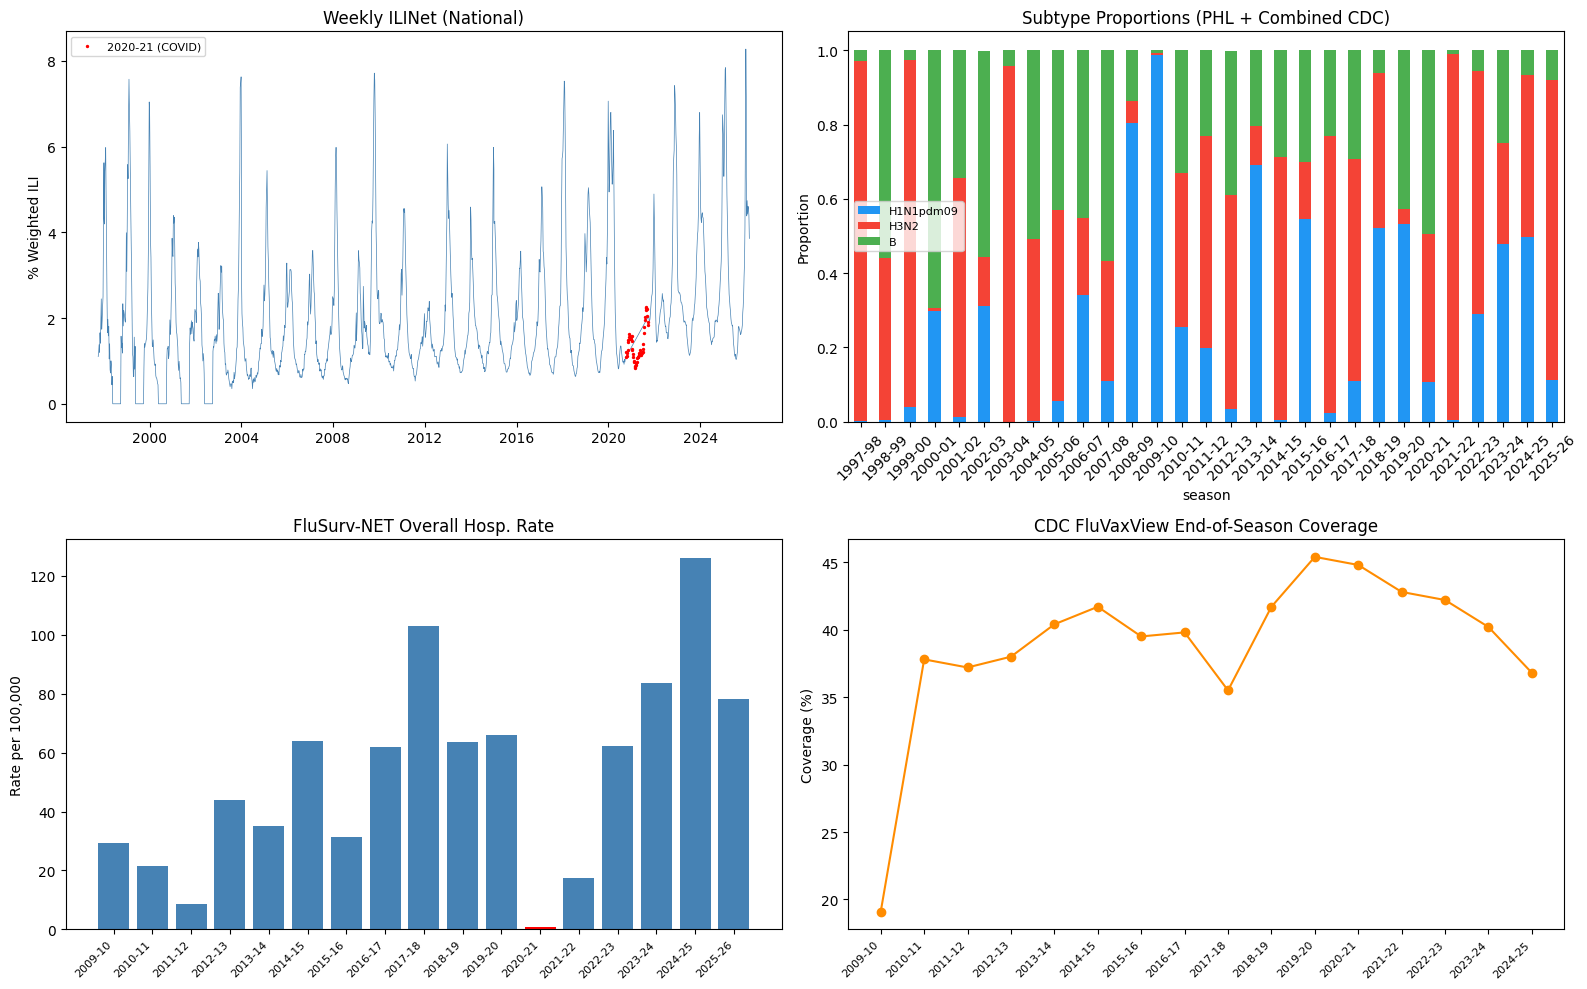

Saved: cdc_data/surveillance_overview.png


In [31]:
# sanity-check plots before we push anything to HuggingFace
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# weekly %ILI over time
ax = axes[0, 0]
if 'pct_weighted_ili' in ilinet_clean.columns:
    ili_plot = ilinet_clean.copy()
    ili_plot['date_approx'] = pd.to_datetime(
        ili_plot['year'].astype(str) + '-W' + ili_plot['week'].astype(str).str.zfill(2) + '-1',
        format='%Y-W%W-%w', errors='coerce'
    )
    covid_mask = ili_plot['covid_excluded']
    ax.plot(ili_plot.loc[~covid_mask, 'date_approx'],
            ili_plot.loc[~covid_mask, 'pct_weighted_ili'],
            linewidth=0.5, color='steelblue')
    ax.scatter(ili_plot.loc[covid_mask, 'date_approx'],
               ili_plot.loc[covid_mask, 'pct_weighted_ili'],
               s=2, color='red', label='2020-21 (COVID)', zorder=5)
    ax.set_ylabel('% Weighted ILI')
    ax.set_title('Weekly ILINet (National)')
    ax.legend(fontsize=8)

# subtype proportions by season
ax = axes[0, 1]
if 'pct_h1n1' in summary.columns:
    dom = summary.set_index('season')
    colors = {'pct_h1n1': '#2196F3', 'pct_h3n2': '#F44336', 'pct_b': '#4CAF50'}
    dom[['pct_h1n1', 'pct_h3n2', 'pct_b']].dropna(how='all').plot(
        kind='bar', stacked=True, ax=ax,
        color=[colors['pct_h1n1'], colors['pct_h3n2'], colors['pct_b']]
    )
    ax.set_ylabel('Proportion')
    ax.set_title('Subtype Proportions (PHL + Combined CDC)')
    ax.legend(['H1N1pdm09', 'H3N2', 'B'], fontsize=8)
    ax.tick_params(axis='x', rotation=45)

# hospitalization rates — red bars flag the COVID season
ax = axes[1, 0]
if flusurv_clean is not None and 'hosp_rate_overall' in flusurv_clean.columns:
    fs = flusurv_clean.copy()
    bar_colors = ['red' if c else 'steelblue' for c in fs['covid_excluded']]
    ax.bar(range(len(fs)), fs['hosp_rate_overall'], color=bar_colors)
    ax.set_xticks(range(len(fs)))
    ax.set_xticklabels(fs['season'], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Rate per 100,000')
    ax.set_title('FluSurv-NET Overall Hosp. Rate')

# vaccination coverage
ax = axes[1, 1]
if 'vax_coverage_pct' in summary.columns:
    vax_plot = summary.dropna(subset=['vax_coverage_pct']).copy()
    ax.plot(vax_plot['season'], vax_plot['vax_coverage_pct'], marker='o', color='darkorange')
    ax.set_xticks(range(len(vax_plot)))
    ax.set_xticklabels(vax_plot['season'], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Coverage (%)')
    ax.set_title('CDC FluVaxView End-of-Season Coverage')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/surveillance_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR}/surveillance_overview.png")


## Step 9: Save CSVs Locally & Push to HuggingFace

In [32]:
datasets_to_save = {
    'ilinet_national': ilinet_clean,
    'who_nrevss_clinical_labs': clinical_clean,
    'who_nrevss_public_health_labs': phl_clean,
    'flusurv_net_rates': flusurv_clean,
    'cdc_burden_estimates': burden_df,
    'season_summary': summary,
}

if 'combined_dominant_df' in globals() and combined_dominant_df is not None and not combined_dominant_df.empty:
    datasets_to_save['who_nrevss_combined_prior'] = combined_dominant_df
if 'vax_by_season' in globals() and vax_by_season is not None and not vax_by_season.empty:
    datasets_to_save['cdc_vaccination_coverage'] = vax_by_season

saved_paths = {}
for name, df in datasets_to_save.items():
    if df is not None and not df.empty:
        path = f"{OUTPUT_DIR}/{name}.csv"
        df.to_csv(path, index=False)
        saved_paths[name] = path
        print(f"Saved {name}: {df.shape} -> {path}")
    else:
        print(f"SKIPPED {name}: empty or None")

print(f"\n{len(saved_paths)} files saved to {OUTPUT_DIR}/")


Saved ilinet_national: (1483, 9) -> cdc_data/ilinet_national.csv
Saved who_nrevss_clinical_labs: (543, 10) -> cdc_data/who_nrevss_clinical_labs.csv
Saved who_nrevss_public_health_labs: (543, 11) -> cdc_data/who_nrevss_public_health_labs.csv
Saved flusurv_net_rates: (17, 5) -> cdc_data/flusurv_net_rates.csv
Saved cdc_burden_estimates: (14, 14) -> cdc_data/cdc_burden_estimates.csv
Saved season_summary: (29, 32) -> cdc_data/season_summary.csv
Saved who_nrevss_combined_prior: (18, 6) -> cdc_data/who_nrevss_combined_prior.csv
Saved cdc_vaccination_coverage: (16, 2) -> cdc_data/cdc_vaccination_coverage.csv

8 files saved to cdc_data/


In [33]:
from huggingface_hub import notebook_login
notebook_login()

In [34]:
# push each processed CSV to cdc_data/ in the HuggingFace dataset repo
from huggingface_hub import HfApi

api = HfApi()

print(f"Uploading processed CSVs to {HF_REPO}/cdc_data/ ...")
for name, path in saved_paths.items():
    api.upload_file(
        path_or_fileobj=path,
        path_in_repo=f"cdc_data/{name}.csv",
        repo_id=HF_REPO,
        repo_type="dataset",
        token = HF_TOKEN
    )
    print(f"  Uploaded: cdc_data/{name}.csv")

plot_path = f"{OUTPUT_DIR}/surveillance_overview.png"
if os.path.exists(plot_path):
    api.upload_file(
        path_or_fileobj=plot_path,
        path_in_repo="cdc_data/surveillance_overview.png",
        repo_id=HF_REPO,
        repo_type="dataset",
        token = HF_TOKEN
    )
    print(f"  Uploaded: cdc_data/surveillance_overview.png")

print(f"\nDone! Files at: https://huggingface.co/datasets/{HF_REPO}/tree/main/cdc_data")

No files have been modified since last commit. Skipping to prevent empty commit.


Uploading processed CSVs to sidms/AML/cdc_data/ ...


No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


  Uploaded: cdc_data/ilinet_national.csv
  Uploaded: cdc_data/who_nrevss_clinical_labs.csv
  Uploaded: cdc_data/who_nrevss_public_health_labs.csv


No files have been modified since last commit. Skipping to prevent empty commit.


  Uploaded: cdc_data/flusurv_net_rates.csv
  Uploaded: cdc_data/cdc_burden_estimates.csv
  Uploaded: cdc_data/season_summary.csv
  Uploaded: cdc_data/who_nrevss_combined_prior.csv
  Uploaded: cdc_data/cdc_vaccination_coverage.csv
  Uploaded: cdc_data/surveillance_overview.png

Done! Files at: https://huggingface.co/datasets/sidms/AML/tree/main/cdc_data


In [35]:
# verify everything landed correctly
from huggingface_hub import list_repo_files

print(f"Files in {HF_REPO}/cdc_data/:")
for f in list_repo_files(HF_REPO, repo_type="dataset"):
    if f.startswith("cdc_data/"):
        print(f"  {f}")

print("\nPipeline complete.")

Files in sidms/AML/cdc_data/:
  cdc_data/FluSurv_rates.csv
  cdc_data/FluViewPhase2Data.zip
  cdc_data/cdc_burden_estimates.csv
  cdc_data/cdc_vaccination_coverage.csv
  cdc_data/flu_burden.csv
  cdc_data/flusurv_net_rates.csv
  cdc_data/ilinet_national.csv
  cdc_data/season_summary.csv
  cdc_data/surveillance_overview.png
  cdc_data/who_nrevss_clinical_labs.csv
  cdc_data/who_nrevss_combined_prior.csv
  cdc_data/who_nrevss_public_health_labs.csv

Pipeline complete.
